In [37]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np 
import itertools
import moocore

import utils.instance_generator as instance_generator

from utils.functions import generate_mask, generate_C2_from_C1

In [38]:
bool_vectors = list(itertools.product([False, True], repeat=10))
bool_vectors = np.array(bool_vectors, dtype=bool)
spin_vectors = 2*bool_vectors-1
spin_vectors.shape

(1024, 10)

In [39]:
matrix0,matrix1,matrix2 = instance_generator.generate_matrices(n=10,ds=0.5,seed=7)

obj0 = 0.5*(matrix0.sum() - (spin_vectors.dot(matrix0)*spin_vectors).sum(axis=1) )
obj1 = 0.5*(matrix1.sum() - (spin_vectors.dot(matrix1)*spin_vectors).sum(axis=1) )
obj2 = 0.5*(matrix2.sum() - (spin_vectors.dot(matrix2)*spin_vectors).sum(axis=1) )
cost = np.array([obj0,obj1,obj2]).T
draw = np.array([obj0+obj1,obj2]).T
answer = moocore.is_nondominated(cost, maximise=True, keep_weakly=False)
pareto = moocore.is_nondominated(draw, maximise=True, keep_weakly=False)
cost[answer].shape,draw[pareto].shape

((511, 3), (31, 2))

In [40]:
# import noise_enhancement
# noise_enhancement.run()

trail_data = np.load('raw_data/NI-SB_data.npy')[1:]

samp_num = 95000*(np.arange(20)+1)

b_mean = trail_data[:,:,0].mean(axis=1)+1
nb_mean = trail_data[:,:,1].mean(axis=1)+1
d_mean = trail_data[:,:,2].mean(axis=1)+1
nd_mean = trail_data[:,:,3].mean(axis=1)+1
b_std = trail_data[:,:,0].std(axis=1)
nb_std = trail_data[:,:,1].std(axis=1)
d_std = trail_data[:,:,2].std(axis=1)
nd_std = trail_data[:,:,3].std(axis=1)

In [41]:
samples_df = pd.read_csv('raw_data/Samples_data.csv')
settings_df = pd.read_csv('raw_data/Settings_data.csv')

In [42]:
settings_dict = settings_df.iloc[0].to_dict()

In [43]:
num_objectives = settings_dict['num_objectives']
batch_size = settings_dict['batch_size']
h_value = settings_dict['batch_size']
num_trials = settings_dict['num_trials']
amp = settings_dict['amp']
n_iter = settings_dict['n_iter']
num_c_vectors = settings_dict['num_c_vectors']
QA_samples = int(settings_dict['QA_samples'])
QAOA_samples = int(settings_dict['QAOA_samples'])
max_pareto_vectors = settings_dict['max_Pareto_solutions']
hv_max = settings_dict['hv_max']

In [44]:
sb_types = ['bSB', 'dSB']

In [45]:
set_basic_font = 14
plt.rcParams.update({      
    "font.size": set_basic_font ,                  
    "axes.labelsize": set_basic_font ,
    "axes.titlesize": set_basic_font ,
    "legend.fontsize": set_basic_font-4 ,
    "xtick.labelsize": set_basic_font ,
    "ytick.labelsize": set_basic_font ,
    "lines.linewidth": 1.2,          
    "lines.markersize": 3,           
})

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12100/2172112755.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('HV$_{\mathrm{max}}$-HV+1')


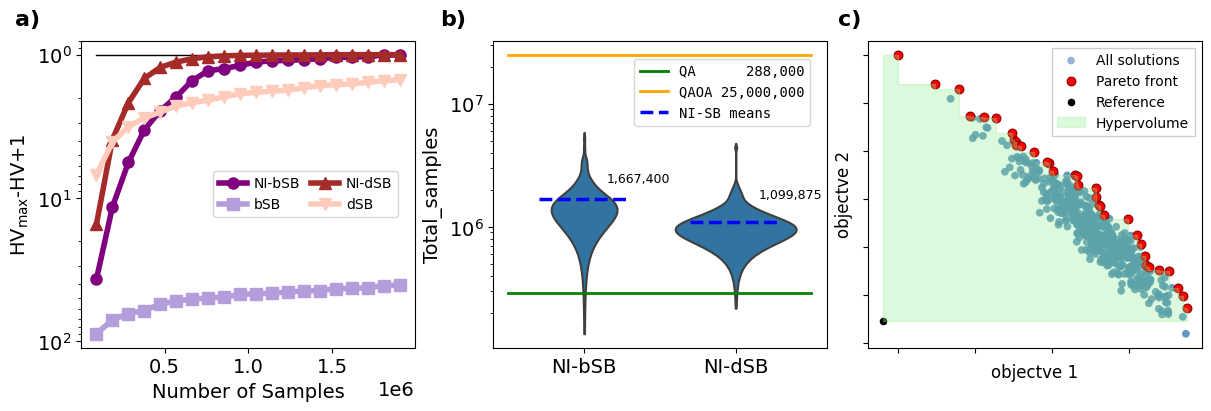

In [46]:

# =============================================================================
# Figure setup
# =============================================================================
fig = plt.figure(figsize=(12, 4), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# =============================================================================
# Subplot (a): Convergence curves
# =============================================================================
ax1.plot(samp_num, np.ones(len(samp_num)), color='black', linewidth=1.0, linestyle='-')
ax1.plot(samp_num, nb_mean, label='NI-bSB',      color='purple',    linewidth=4, marker='o', markersize=8)
ax1.plot(samp_num, b_mean,   label='bSB',        color='#B39DDB',   linewidth=4, marker='s', markersize=8)
ax1.plot(samp_num, nd_mean, label='NI-dSB',      color='brown',     linewidth=4, marker='^', markersize=8)
ax1.plot(samp_num, d_mean,   label='dSB',        color='#FFCCBC',   linewidth=4, marker='v', markersize=8)

ax1.set_yscale('log')
ax1.invert_yaxis()  # Larger values appear at the bottom

ax1.set_xlabel('Number of Samples')
ax1.set_ylabel('HV$_{\mathrm{max}}$-HV+1')

ax1.legend(
    frameon=True,
    loc='center right',
    bbox_to_anchor=(0.95, 0.5),
    borderaxespad=0,
    handletextpad=0.5,
    columnspacing=0.8,
    ncol=2,
)

# Panel label
ax1.text(-0.2, 1.05, 'a)', transform=ax1.transAxes, fontweight='bold', fontsize=16)

# =============================================================================
# Subplot (b): Violin plot of sample sizes
# =============================================================================
sns.violinplot(
    data=samples_df, ax=ax2, x='SB', y='sample_size',
    inner=None, linewidth=1.5,
)

left_l, right_l = -0.5, 1.5
ax2.plot([left_l, right_l], [QA_samples, QA_samples],
         color='green', linewidth=2, label=f'{"QA":<5}{QA_samples:>10,}')
ax2.plot([left_l, right_l], [QAOA_samples, QAOA_samples],
         color='orange', linewidth=2, label=f'{"QAOA":<5}{QAOA_samples:>9,}')

# Mean horizontal lines
means = samples_df.groupby('SB')['sample_size'].mean()
mean_values = [means[algo] for algo in sb_types]
x_positions = range(len(sb_types))

ax2.hlines(
    y=mean_values,
    xmin=[i - 0.3 for i in x_positions],
    xmax=[i + 0.3 for i in x_positions],
    colors='blue', linewidths=2.5, linestyles='dashed',
    zorder=3, label='NI-SB means',
)

for i, algo in enumerate(sb_types):

    ax2.text(
        x=i + 0.15,                 # 2% from the left edge (axes coordinates: 0 to 1)
        y=means[algo]+0.5*10**6,             # Aligns with the line (data coordinates)
        s=f'{int(means[algo]):,}', # The text
        # transform=ax2.get_yaxis_transform(), # Mixes axes(x) + data(y)
        va='bottom',            # Vertically centered on the line
        ha='left',              # Left-aligned text
        fontsize=9,
        color='black',
        # fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3) # Optional: subtle background
    )

ax2.set_xticks(x_positions)
ax2.set_xticklabels(['NI-' + x for x in sb_types])
ax2.set_ylabel('Total_samples')
ax2.set_xlabel(None)
ax2.set_yscale('log')

ax2.legend(
    loc='lower right', bbox_to_anchor=(0.971, 0.7),
    bbox_transform=ax2.transAxes, frameon=True,
    prop={'family': 'monospace'},
)

# Panel label
ax2.text(-0.16, 1.05, 'b)', transform=ax2.transAxes, fontweight='bold', fontsize=16)

# =============================================================================
# Subplot (c): Pareto front & Hypervolume
# =============================================================================
# All solutions
ax3.scatter(
    obj0 + obj1, obj2,
    s=30, alpha=0.6, color='steelblue', edgecolors='none',
    label='All solutions',
)

# Pareto front
ax3.scatter(
    draw[pareto, 0], draw[pareto, 1],
    s=40, color='red', marker='o',
    edgecolors='darkred', linewidth=0.8,
    label='Pareto front',
)

# Hypervolume calculation
pf = draw[pareto]
pf = pf[pf[:, 0].argsort()]  # Sort by first objective (ascending)

min_x, min_y = pf[:, 0].min(), pf[:, 1].min()
margin_x = max(10, (pf[:, 0].max() - min_x) * 0.05)
margin_y = max(100, (pf[:, 1].max() - min_y) * 0.05)
ref_x = min_x - margin_x
ref_y = min_y - margin_y

x_vals = [ref_x] + list(pf[:, 0])
max_y = pf[:, 1].max()
y_vals = [max_y] + list(pf[:, 1])

ax3.scatter(ref_x, ref_y, s=20, color='black', label='Reference')
ax3.fill_between(
    x_vals, y_vals, ref_y,
    step='pre', color='lightgreen', alpha=0.3,
    label='Hypervolume',
)

ax3.set_xlabel('objectve 1', fontsize=12)
ax3.set_ylabel('objectve 2', fontsize=12)
ax3.set_xticklabels([])
ax3.set_yticklabels([])

ax3.legend(frameon=True, fancybox=False, shadow=False, framealpha=0.95)

# Panel label
ax3.text(-0.09, 1.05, 'c)', transform=ax3.transAxes, fontweight='bold', fontsize=16)

# =============================================================================
# Save figure
# =============================================================================

# fig.savefig('Fig3.pdf', bbox_inches='tight', dpi=300)